# Species comparison
## Independent analysis of lncRNA and TF transcripts
### Author: Martin Loza
### Date: 26/01/14
We will investigate the results from liftedover region 

In [35]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggalluvial)
})

# Local variables 
seed = 777
date = "260114"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
dark_green = "#2B7A0B"
purple = "#984EA3"
orange = "#FF7F00"
dark_orange = "#A65628"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

regions_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Liftover/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/06_Species_comparison_lncRNA_TF/Plots/"

# Local Functions

# Create a conservation matrix for each gene type (lncRNA and TF)
# We'll track whether each region from human has an ortholog in other species

# Function to create conservation data
create_conservation_data <- function(regions_list, gene_type) {
    # Get all species for this gene type
    species_data <- regions_list[grepl(paste0("_", gene_type), names(regions_list))]
    
    if (length(species_data) == 0) {
        return(NULL)
    }
    
    # Extract species names
    species_names <- sapply(names(species_data), function(x) {
        str_split(x, "_")[[1]][1]
    })
    
    # Human is the reference (or first species)
    ref_idx <- which(species_names == "human")
    if (length(ref_idx) == 0) {
        ref_idx <- 1  # Use first species as reference if no human
    }
    
    reference_species <- species_names[ref_idx]
    reference_data <- species_data[[ref_idx]]
    reference_regions <- reference_data$name
    
    # Create a matrix to track conservation
    conservation_df <- data.frame(
        region = reference_regions,
        stringsAsFactors = FALSE
    )
    
    # Add reference species first (all will be "Present")
    conservation_df[[reference_species]] <- "Present"
    
    # For each non-reference species, check if the region is present
    for (i in seq_along(species_data)) {
        sp_name <- species_names[i]
        
        # Skip the reference species since we already added it
        if (sp_name == reference_species) {
            next
        }
        
        sp_regions <- species_data[[i]]$name
        
        # Create a column indicating presence/absence
        conservation_df[[sp_name]] <- ifelse(
            conservation_df$region %in% sp_regions,
            "Present",
            "Absent"
        )
    }
    
    return(list(
        data = conservation_df,
        reference = reference_species,
        gene_type = gene_type
    ))
}

# Prepare data for alluvial plots
prepare_alluvial_data <- function(conservation_result) {
    if (is.null(conservation_result)) {
        return(NULL)
    }
    
    df <- conservation_result$data
    
    # Count the frequency of each conservation pattern
    # We'll aggregate by all species columns (excluding region column)
    species_cols <- setdiff(names(df), "region")
    
    # Count patterns
    pattern_counts <- df %>%
        group_by(across(all_of(species_cols))) %>%
        summarise(Freq = n(), .groups = "drop") 
    
    return(pattern_counts)
}



# Function to create alluvial plot
create_alluvial_plot <- function(alluvial_data, gene_type, species_order = NULL) {
    if (is.null(alluvial_data) || nrow(alluvial_data) == 0) {
        cat(paste0("No data available for ", gene_type, "\n"))
        return(NULL)
    }
    
    # Get species columns (all except Freq)
    species_cols <- setdiff(names(alluvial_data), "Freq")
    
    # Reorder species if specified, otherwise order by conservation level
    if (!is.null(species_order)) {
        species_cols <- intersect(species_order, species_cols)
    } else {
        # Calculate conservation percentage for each species (excluding human)
        other_species <- setdiff(species_cols, "human")
        
        if (length(other_species) > 0) {
            conservation_pct <- sapply(other_species, function(sp) {
                sum((alluvial_data[[sp]] == "Present") * alluvial_data$Freq) / sum(alluvial_data$Freq)
            })
            
            # Order species by conservation percentage (descending)
            ordered_species <- other_species[order(conservation_pct, decreasing = TRUE)]
            
            # Place human first, then ordered species
            if ("human" %in% species_cols) {
                species_cols <- c("human", ordered_species)
            } else {
                species_cols <- ordered_species
            }
        } else if ("human" %in% species_cols) {
            species_cols <- c("human")
        }
    }
    
    # Create new status columns with three levels: "Conserved in all", "Present", "Absent"
    # For patterns conserved in all species, replace "Present" with "Conserved in all"
    for (sp in species_cols) {
        alluvial_data[[sp]] <- as.character(alluvial_data[[sp]])
    }
    
    # Identify patterns conserved in all species
    conserved_all_rows <- apply(alluvial_data[, species_cols, drop = FALSE], 1, function(row) {
        all(row == "Present")
    })
    
    # Replace "Present" with "Ortholog all species" for conserved patterns
    for (sp in species_cols) {
        alluvial_data[[sp]][conserved_all_rows] <- "Ortholog all species"
    }
    
    # Build the aesthetic mapping dynamically
    aes_mapping <- list(y = quote(Freq))
    for (i in seq_along(species_cols)) {
        axis_name <- paste0("axis", i)
        aes_mapping[[axis_name]] <- as.name(species_cols[i])
    }
    
    # Set colors based on gene type
    if (gene_type == "lncRNA") {
        color_ortholog_all <- dark_orange
        color_ortholog <- orange
    } else {
        # For TF, use green colors
        color_ortholog_all <- dark_green  # Darker green
        color_ortholog <- green
    }
    
    # Create the plot with single flow layer colored by destination
    p <- ggplot(alluvial_data, do.call(aes, aes_mapping)) +
        geom_flow(aes(fill = after_stat(stratum)), width = 1/4, alpha = 0.7) +
        geom_stratum(aes(fill = after_stat(stratum)), width = 1/4, color = "grey30", alpha = 1) +
        scale_fill_manual(
            values = c("Ortholog all species" = color_ortholog_all, "Present" = color_ortholog, "Absent" = "grey70"),
            breaks = c("Ortholog all species", "Present", "Absent"),
            labels = c("Ortholog all species", "Ortholog", "Non-ortholog"),
            guide = guide_legend(nrow = 1, byrow = TRUE)
        ) +
        scale_x_discrete(
            limits = species_cols, 
            expand = c(.05, .05),
            labels = function(x) ifelse(x == "elegans", "C. elegans", x)
        ) +
        labs(
            title = paste0("Conservation of ", gene_type, " regions across species"),
            y = "Number of regions",
            fill = "Region\nstatus"
        ) +
        theme_minimal(base_size = text_size) +
        theme(
            text = element_text(size = text_size),
            axis.text.y = element_text(size = text_size - 2),
            plot.title = element_text(size = text_size + 1, hjust = 0.5),
            legend.position = "bottom",
            # legend.title = element_text(margin = margin(b = 2, unit = "pt")),
            legend.text = element_text(margin = margin(r = 25, unit = "pt")),
            legend.key.width = unit(0.6, "cm"),
            axis.text.x = element_text(angle = 45, hjust = 1)
        )
    
    return(p)
}



### Load and setup the data

In [17]:
# We have different species, so let's create a list to store the data
regions_list = list()

# Search for the available files
files <- list.files(regions_dir)

# The files contain the species, genome, and gene type information, e.g. dog_canFam6_lncRNA_liftover.bed
for (file in files) {
    # Split the file name to extract information
    parts <- str_split(file, "_")[[1]]
    species <- parts[1]
    genome <- parts[2]
    gene_type <- parts[3]
    
    # Read the bed file
    bed_data <- read.table(file.path(regions_dir, file), header = FALSE, stringsAsFactors = FALSE)
    # set column names, in the case of human, we have a missing column, since there are no match_id
    if(ncol(bed_data) == 4) {
        bed_data$match_id <- 1
    }
    # Set column names
    colnames(bed_data) <- c("chrom", "start", "end", "name", "match_id")
    
    # Store in the list with a descriptive name
    list_name <- paste(species, genome, gene_type, sep = "_")
    regions_list[[list_name]] <- bed_data
}


Some regions matched to two different locus, so we have multiple match_ids.

For those regions, let's chose the one with the largest match, e.g., widest one.

In [18]:
# Add the width to each region
for (name in names(regions_list)) {
    regions_list[[name]] <- regions_list[[name]] %>%
        mutate(width = end - start)
}

# In case there are multiple match_id per name, we chose the widest region
for (name in names(regions_list)) {
    regions_list[[name]] <- regions_list[[name]] %>%
        group_by(name) %>%
        slice_max(order_by = width, n = 1, with_ties = FALSE) %>%
        ungroup()
}

# Check that all regions have only one entry per name
for (name in names(regions_list)) {
    dup_names <- regions_list[[name]] %>%
        group_by(name) %>%
        filter(n() > 1) %>%
        pull(name) %>%
        unique()
    if (length(dup_names) > 0) {
        cat(paste("Warning: There are duplicate names in", name, "\n"))
    }
}

### Conservation analysis

Now let's investigate the conservation of lncRNA and TF genes across species using alluvial plots.

In [19]:
# Let's see what species and gene types we have
cat("Available datasets:\n")
for (name in names(regions_list)) {
    cat(paste0("  - ", name, ": ", nrow(regions_list[[name]]), " regions\n"))
}

Available datasets:
  - armadillo_dasNov3_lncRNA: 9888 regions
  - armadillo_dasNov3_tf: 1790 regions
  - chicken_galGal6_lncRNA: 6403 regions
  - chicken_galGal6_tf: 1245 regions
  - dog_canFam6_lncRNA: 10080 regions
  - dog_canFam6_tf: 1826 regions
  - droshopila_BDGPdm6_lncRNA: 398 regions
  - droshopila_BDGPdm6_tf: 97 regions
  - elegans_WBcel235_lncRNA: 120 regions
  - elegans_WBcel235_tf: 28 regions
  - ferret_musFur1_lncRNA: 10037 regions
  - ferret_musFur1_tf: 1804 regions
  - human_hg38_lncRNA: 10637 regions
  - human_hg38_tf: 1915 regions
  - macaque_rheMac10_lncRNA: 10523 regions
  - macaque_rheMac10_tf: 1905 regions
  - mouse_mm39_lncRNA: 9086 regions
  - mouse_mm39_tf: 1660 regions
  - rat_rn7_lncRNA: 9124 regions
  - rat_rn7_tf: 1656 regions
  - zebrafish_danRer11_lncRNA: 2067 regions
  - zebrafish_danRer11_tf: 539 regions


In [20]:
# Create conservation data for lncRNA and TF
lncRNA_conservation <- create_conservation_data(regions_list, "lncRNA")
TF_conservation <- create_conservation_data(regions_list, "tf")

cat("Conservation data created.\n")
if (!is.null(lncRNA_conservation)) {
    cat(paste0("lncRNA: ", nrow(lncRNA_conservation$data), " regions from ", 
               lncRNA_conservation$reference, "\n"))
}
if (!is.null(TF_conservation)) {
    cat(paste0("TF: ", nrow(TF_conservation$data), " regions from ", 
               TF_conservation$reference, "\n"))
}

Conservation data created.
lncRNA: 10637 regions from human
TF: 1915 regions from human


In [21]:
# Prepare alluvial data
lncRNA_alluvial <- prepare_alluvial_data(lncRNA_conservation)
TF_alluvial <- prepare_alluvial_data(TF_conservation)

cat("Alluvial data prepared.\n")
if (!is.null(lncRNA_alluvial)) {
    cat(paste0("lncRNA: ", nrow(lncRNA_alluvial), " unique conservation patterns\n"))
    cat(paste0("Total regions: ", sum(lncRNA_alluvial$Freq), "\n"))
}
if (!is.null(TF_alluvial)) {
    cat(paste0("TF: ", nrow(TF_alluvial), " unique conservation patterns\n"))
    cat(paste0("Total regions: ", sum(TF_alluvial$Freq), "\n"))
}

Alluvial data prepared.
lncRNA: 76 unique conservation patterns
Total regions: 10637
TF: 62 unique conservation patterns
Total regions: 1915


Get some general numbers

In [26]:
tmp_lncRNA <- lncRNA_conservation$data %>%
                mutate(Freq = rowSums(across(-region, ~ . == "Present")))
tmp_tf <- TF_conservation$data %>%
                mutate(Freq = rowSums(across(-region, ~ . == "Present")))

cat("Number of lncRNA regions conserved in all species: ", 
    sum(tmp_lncRNA$Freq == ncol(tmp_lncRNA) - 2), "\n")
cat("Number of TF regions conserved in all species: ", 
    sum(tmp_tf$Freq == ncol(tmp_tf) - 2), "\n")

Number of lncRNA regions conserved in all species:  113 
Number of TF regions conserved in all species:  26 


In [28]:
summary(tmp_lncRNA$Freq)
summary(tmp_tf$Freq)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   7.000   8.000   7.367   8.000  11.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   7.000   8.000   7.554   9.000  11.000 

In [29]:
cat("Number of lncRNA regions conserved in more than 8 species: ", 
    sum(tmp_lncRNA$Freq > 8), "\n")
cat("Number of TF regions conserved in more than 8 species: ", 
    sum(tmp_tf$Freq > 8), "\n")

Number of lncRNA regions conserved in more than 8 species:  1887 
Number of TF regions conserved in more than 8 species:  511 


### Create alluvial plots

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


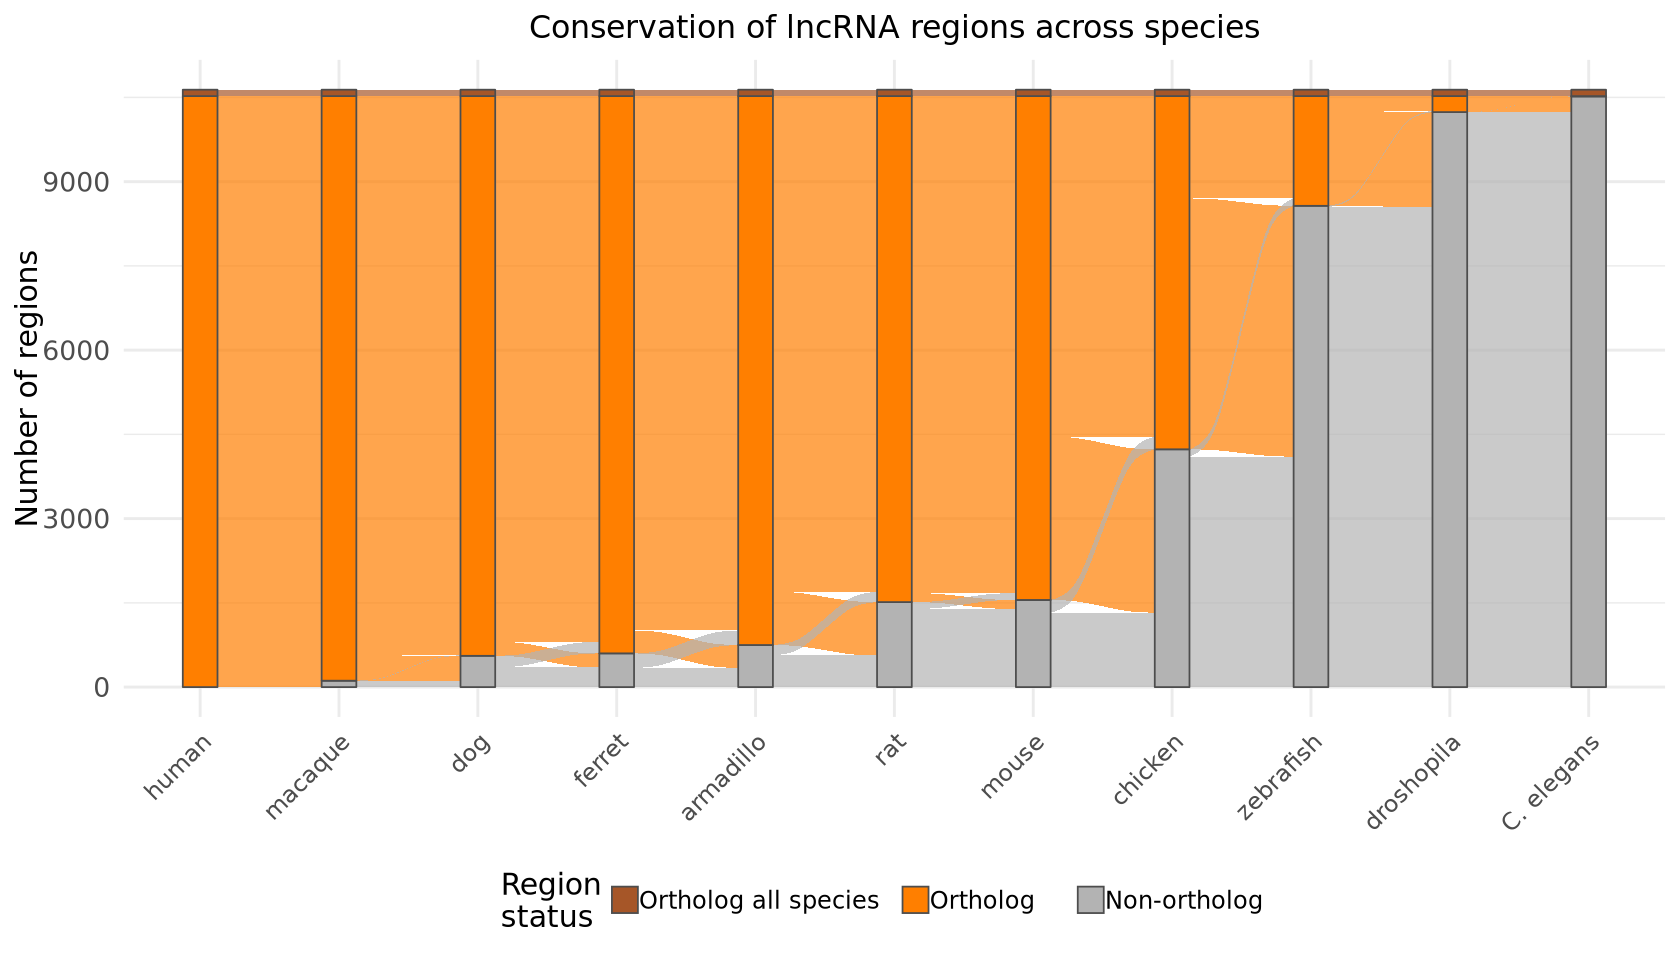

In [36]:
options(repr.plot.width=14, repr.plot.height=8)
# Create plots for lncRNA
if (!is.null(lncRNA_alluvial)) {
    lncRNA_plot <- create_alluvial_plot(lncRNA_alluvial, "lncRNA")
    if (!is.null(lncRNA_plot)) {
        print(lncRNA_plot)
    }
}

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


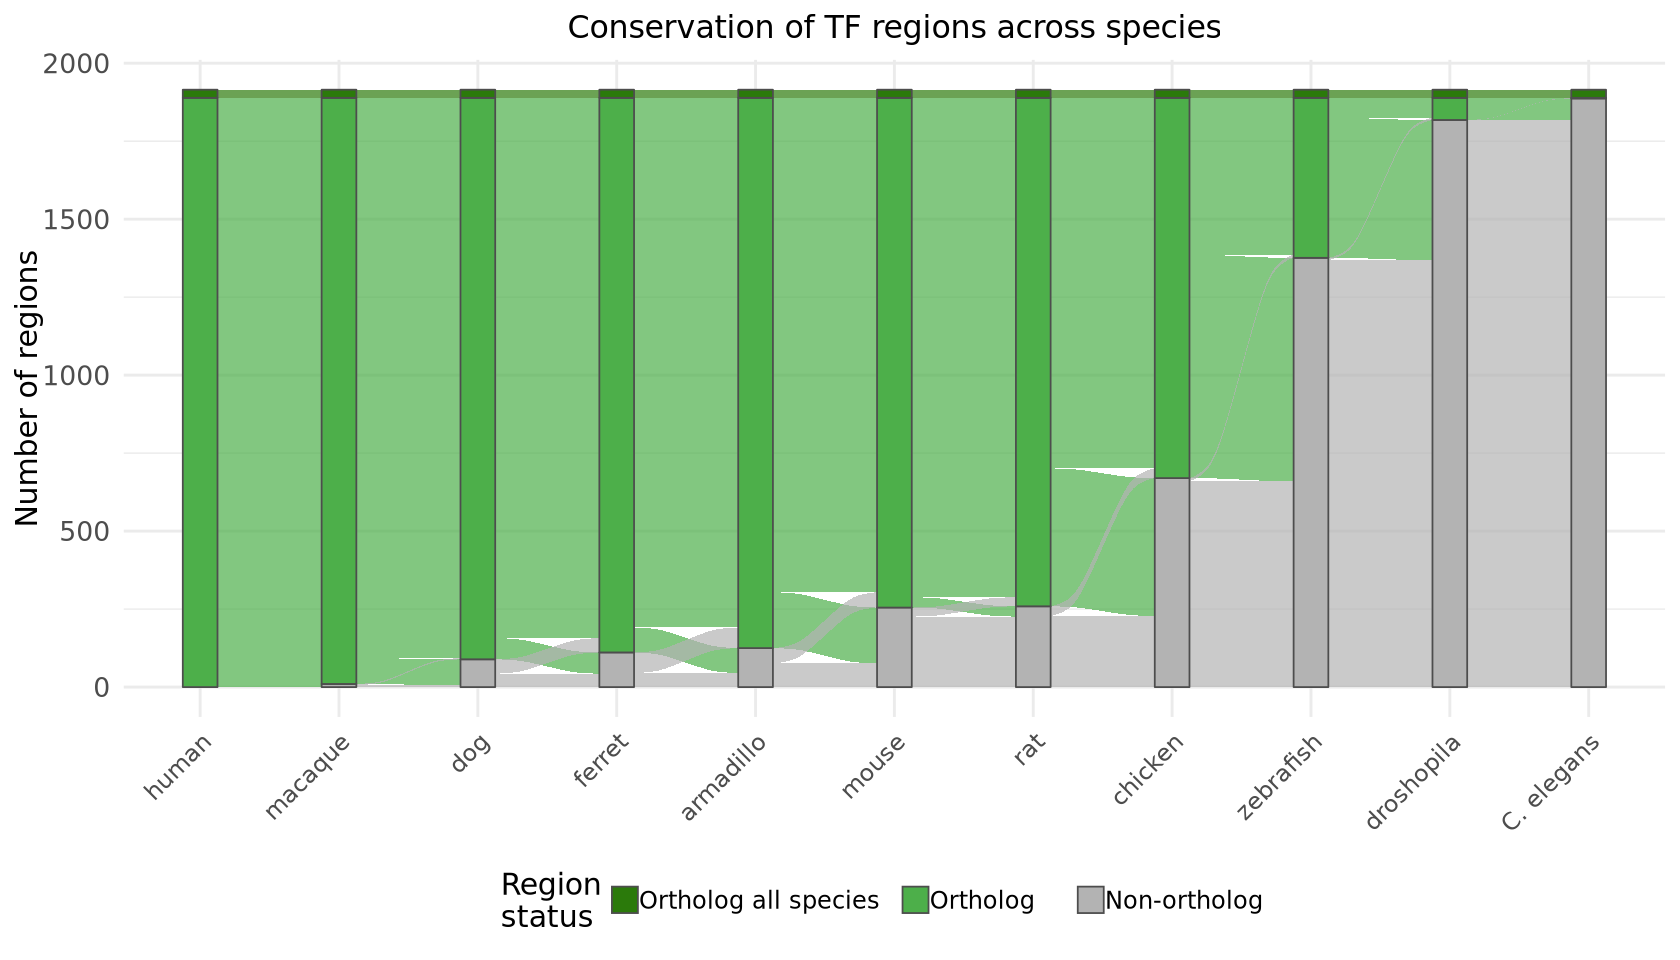

In [37]:
# Create plots for TF
if (!is.null(TF_alluvial)) {
    TF_plot <- create_alluvial_plot(TF_alluvial, "TF")
    if (!is.null(TF_plot)) {
        print(TF_plot)
    }
}

### Save plots


In [ ]:
# Save the lncRNA conservation plot
ggsave(filename = file.path(out_dir, paste0("Supplementary_lncRNA_orthologs_", date, ".pdf")),
    plot = lncRNA_plot, 
    width = width * 0.9, height = 8.0, units = "in", dpi = dpi)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


In [38]:
# Save the TF conservation plot
ggsave(filename = file.path(out_dir, paste0("Supplementary_TF_orthologs_", date, ".pdf")),
    plot = TF_plot, 
    width = width * 0.9, height = 8.0, units = "in", dpi = dpi)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
